In [5]:
import os
import torch
from data import create_dataset
from model import create_model
# from util.visualizer import save_images
# from util import html
import matplotlib.pyplot as plt
import argparse

In [6]:
parser = argparse.ArgumentParser(formatter_class=argparse.ArgumentDefaultsHelpFormatter)
# basic parameters
parser.add_argument('--dataroot', default='datasets/', help='path to images (should have subfolders trainA, trainB, valA, valB, etc)')
parser.add_argument('--datatype', default='text', help='type of dataset (image dataset have subfolders, text dataset has files)')
parser.add_argument('--name', type=str, default='experiment_name', help='name of the experiment. It decides where to store samples and models')
parser.add_argument('--gpu_ids', type=str, default='0', help='gpu ids: e.g. 0  0,1,2, 0,2. use -1 for CPU')
parser.add_argument('--checkpoints_dir', type=str, default='./checkpoints', help='models are saved here')
# model parameters
parser.add_argument('--model', type=str, default='cycle_gan', help='chooses which model to use. [cycle_gan | pix2pix | test | colorization]')
parser.add_argument('--input_nc', type=int, default=3, help='# of input image channels: 3 for RGB and 1 for grayscale')
parser.add_argument('--output_nc', type=int, default=3, help='# of output image channels: 3 for RGB and 1 for grayscale')
parser.add_argument('--ngf', type=int, default=64, help='# of gen filters in the last conv layer')
parser.add_argument('--ndf', type=int, default=64, help='# of discrim filters in the first conv layer')
parser.add_argument('--netD', type=str, default='basic', help='specify discriminator architecture [basic | n_layers | pixel]. The basic model is a 70x70 PatchGAN. n_layers allows you to specify the layers in the discriminator')
parser.add_argument('--netG', type=str, default='resnet_9blocks', help='specify generator architecture [resnet_9blocks | resnet_6blocks | unet_256 | unet_128 | dense | transformer]')
parser.add_argument('--n_layers_D', type=int, default=3, help='only used if netD==n_layers')
parser.add_argument('--norm', type=str, default='instance', help='instance normalization or batch normalization [instance | batch | none]')
parser.add_argument('--init_type', type=str, default='normal', help='network initialization [normal | xavier | kaiming | orthogonal]')
parser.add_argument('--init_gain', type=float, default=0.02, help='scaling factor for normal, xavier and orthogonal.')
parser.add_argument('--no_dropout', action='store_true', help='no dropout for the generator')
# dataset parameters
parser.add_argument('--dataset_mode', type=str, default='unaligned', help='chooses how datasets are loaded. [unaligned | aligned | single | colorization | unalignedpaired]')
parser.add_argument('--direction', type=str, default='AtoB', help='AtoB or BtoA')
parser.add_argument('--serial_batches', action='store_true', help='if true, takes images in order to make batches, otherwise takes them randomly')
parser.add_argument('--num_threads', default=4, type=int, help='# threads for loading data')
parser.add_argument('--batch_size', type=int, default=1, help='input batch size')
parser.add_argument('--load_size', type=int, default=286, help='scale images to this size')
parser.add_argument('--crop_size', type=int, default=256, help='then crop to this size')
parser.add_argument('--max_dataset_size', type=int, default=float("inf"), help='Maximum number of samples allowed per dataset. If the dataset directory contains more than max_dataset_size, only a subset is loaded.')
parser.add_argument('--preprocess', type=str, default='resize_and_crop', help='scaling and cropping of images at load time [resize_and_crop | crop | scale_width | scale_width_and_crop | none]')
parser.add_argument('--no_flip', action='store_true', help='if specified, do not flip the images for data augmentation')
parser.add_argument('--display_winsize', type=int, default=256, help='display window size for both visdom and HTML')
# additional parameters
parser.add_argument('--epoch', type=str, default='latest', help='which epoch to load? set to latest to use latest cached model')
parser.add_argument('--load_iter', type=int, default='0', help='which iteration to load? if load_iter > 0, the code will load models by iter_[load_iter]; otherwise, the code will load models by [epoch]')
parser.add_argument('--suffix', default='', type=str, help='customized suffix: opt.name = opt.name + suffix: e.g., {model}_{netG}_size{load_size}')
parser.add_argument('--results_dir', type=str, default='./results/', help='saves results here.')
parser.add_argument('--aspect_ratio', type=float, default=1.0, help='aspect ratio of result images')
parser.add_argument('--phase', type=str, default='test', help='train, val, test, etc')
# Dropout and Batchnorm has different behavioir during training and test.
parser.add_argument('--eval', action='store_true', help='use eval mode during test time.')
parser.add_argument('--num_test', type=int, default=249, help='how many test images to run')

_StoreAction(option_strings=['--num_test'], dest='num_test', nargs=None, const=None, default=249, type=<class 'int'>, choices=None, required=False, help='how many test images to run', metavar=None, deprecated=False)

### NCI60 analysis

In [7]:
import ntpath
import scipy.stats as stats
import pandas as pd
import os, re

In [19]:
#Manually load the shape of input data (particular the size of features)
# ag_file = 'datasets/NCI60/NCI603_ag.tsv'
ag_file = 'datasets/TCGA/LUSC/LUSC1_ag.tsv'
#ag_file = 'datasets/NB/NB_AG.csv'
if ag_file.endswith('xlsx'):
    df_ag = pd.read_excel(ag_file,index_col=0)
    input_nc = df_ag.shape[1]
elif 'NB' in ag_file:
    input_nc = 10042
elif ag_file.endswith('tsv'):
    df_ag = pd.read_csv(ag_file,sep="\t", index_col=0)
    input_nc = df_ag.shape[1]
print(input_nc)

15889


In [20]:
files = os.listdir('run_datasets/datasets_LUSC1/tmp_10_0/testAG/')
print(len(files))

140


In [21]:
from tqdm.notebook import tqdm

res=[]
exp = 'LUSC1'
epochs = [4501,]
sizes = [10,]
repeats = [0,]

if not os.path.exists(f'results/{exp}'):
    os.system(f'mkdir results/{exp}')

for sample_size in sizes:
    for rep in repeats:
        for epoch in epochs:
            opt = parser.parse_args(args=[])
            # Convert args to a dictionary
            opt.datatype = 'text'  # Dataset type (text or image)
            opt.phase = 'test'  # Phase: train, val, or test
            opt.dataset_mode = 'unalignedpaired'  # Dataset mode
            opt.batch_size = 1  # Batch size
            # Model and training/testing configurations
            opt.aspect_ratio = 1.0  # Aspect ratio of output images
            opt.num_test = len(files)  # Number of test samples
            opt.eval = True  # Use evaluation mode
            opt.model = 'trans_cycle_gan'  # Model type (cycle_gan, pix2pix, etc.)
            opt.input_nc =  input_nc #7864 #8784  # Number of input channels (3 for RGB, 1 for grayscale)
            opt.output_nc = input_nc #8784  # Number of output channels
            opt.netD = 'fullyconnected'
            opt.netG = 'fullyconnected'
            opt.norm = 'instance'  # Normalization type
            opt.no_dropout = True  # Disable dropout in generator
            opt.serial_batches = True  # Ensure ordered image loading
            opt.num_threads = 0  # Number of data loading threads
            opt.display_winsize = 256  # Display window size
            opt.isTrain=False
            opt.dataroot = f'./run_datasets/datasets_{exp}/tmp_{sample_size}_{rep}'  # Path to dataset
            opt.ckp_dir = f'./run_logs/run_{exp}/'  # Directory for checkpoints
            opt.checkpoints_dir = opt.ckp_dir
            opt.name = f'SampleSize_{sample_size}_{rep}'  # Experiment name
            opt.results_dir = './Inference/'  # Directory for results
            opt.model_suffix = 'A'  # Model suffix
            opt.epoch = epoch  # Epoch to load
            opt.verbose=False
            opt.gpu_ids='7'
            
            dataset = create_dataset(opt)
            model = create_model(opt)      # create a model given opt.model and other options
            model.setup(opt)
            
            list_DEG_a = {}
            list_DEG_a_gen = {}
            list_DEG_b = {}
            list_DEG_b_gen = {}
            
            skipped_count = 0
            for i, data in tqdm(enumerate(dataset)):
                try:
                    model.set_input(data)
                    model.test()
                    visuals = model.get_current_visuals()
                    
                    # Initialize variables
                    real_a = real_b = fake_a = fake_b = None
                    
                    for label, im_data in visuals.items():
                        if label == 'real_A':
                            real_a = im_data
                        elif label == 'real_B':
                            real_b = im_data
                        elif label == 'fake_A':
                            fake_a = im_data
                        elif label == 'fake_B':
                            fake_b = im_data
                    
                    # Check if all required data is available
                    if None in [real_a, real_b, fake_a, fake_b]:
                        logging.warning(f"Missing required data in visuals for item {i}")
                        skipped_count += 1
                        continue
                    
                    img_path = model.get_image_paths()
                    short_path = ntpath.basename(img_path[0])
                    name = os.path.splitext(short_path)[0]
                    
                    list_DEG_a[name] = real_a.flatten().cpu().numpy()
                    list_DEG_a_gen[name] = fake_a.flatten().cpu().numpy()
                    list_DEG_b[name] = real_b.flatten().cpu().numpy()
                    list_DEG_b_gen[name] = fake_b.flatten().cpu().numpy()
                    
                except Exception as e:
                    print(e)
                    skipped_count += 1
                    break
                
            # we don't need to save all genearted files for DEG analysis    
            if True:
                
                df_microarray = pd.DataFrame(list_DEG_a, )
                df_rnaseq = pd.DataFrame(list_DEG_b, )
                df_microarray_fake = pd.DataFrame(list_DEG_a_gen, )
                df_rnaseq_fake = pd.DataFrame(list_DEG_b_gen, )
            
                if not os.path.exists(f'./results/{exp}/{exp}_{sample_size}_ep{epoch}_{rep}'):
                    os.system(f'mkdir ./results/{exp}/{exp}_{sample_size}_ep{epoch}_{rep}')
                df_microarray.transpose().to_csv(f'./results/{exp}/{exp}_{sample_size}_ep{epoch}_{rep}/Microarray_real.csv')
                df_microarray_fake.transpose().to_csv(f'./results/{exp}/{exp}_{sample_size}_ep{epoch}_{rep}/Microarray_fake.csv')
                df_rnaseq.transpose().to_csv(f'./results/{exp}/{exp}_{sample_size}_ep{epoch}_{rep}/RNAseq_real.csv')
                df_rnaseq_fake.transpose().to_csv(f'./results/{exp}/{exp}_{sample_size}_ep{epoch}_{rep}/RNAseq_fake.csv')

dataset [UnalignedPairedDataset] was created
initialize network with normal
initialize network with normal
model [transcycleganmodel] was created
loading the model from ./run_logs/run_LUSC1/SampleSize_10_0/4501_net_G_A.pth
loading the model from ./run_logs/run_LUSC1/SampleSize_10_0/4501_net_G_B.pth
---------- Networks initialized -------------
[Network G_A] Total number of parameters : 252.468 M
[Network G_B] Total number of parameters : 252.468 M
-----------------------------------------------


0it [00:00, ?it/s]

## Clustering analysis

In [1]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

def create_tsne_visualization_seaborn(df_ma_real, df_rs_real, df_rs_fake, df_ma_fake):
    """
    Create t-SNE visualization using seaborn for enhanced styling
    """
    
    # Combine data and create labels
    combined_data = np.vstack([
        df_ma_real.values,
        df_ma_fake.values,
        df_rs_real.values, 
        df_rs_fake.values        
    ])
    
    labels = ['MA Real'] * len(df_ma_real) + \
             ['MA Fake'] * len(df_ma_fake) + \
             ['RS Real'] * len(df_rs_real) + \
             ['RS Fake'] * len(df_rs_fake)
             
    
    # Standardize and apply t-SNE
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(combined_data)
    
    print("Applying t-SNE transformation...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    tsne_results = tsne.fit_transform(scaled_data)
    
    # Create DataFrame for seaborn
    tsne_df = pd.DataFrame({
        'TSNE1': tsne_results[:, 0],
        'TSNE2': tsne_results[:, 1],
        'Group': labels
    })
    
    # Create the plot
    plt.figure(figsize=(6, 8))
    sns.scatterplot(
        data=tsne_df,
        x='TSNE1',
        y='TSNE2',
        hue='Group',
        palette=['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c'],
        alpha=0.7,
        s=60
    )
    
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.title('t-SNE Visualization of Four Datasets')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return tsne_results, labels

In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

def create_pca_visualization_seaborn(df_ma_real, df_rs_real, df_rs_fake, df_ma_fake):
    """
    Create a PCA visualization (2D) using seaborn for enhanced styling.

    Parameters
    ----------
    df_ma_real, df_rs_real, df_rs_fake, df_ma_fake : pd.DataFrame
        Samples in rows, genes/features in columns (same feature ordering across all).

    Returns
    -------
    pca_results : np.ndarray, shape (n_samples, 2)
        Coordinates of each sample on PC1/PC2.
    labels : list of str
        Group label for each sample in pca_results.
    """
    # Combine data and create labels
    combined_data = np.vstack([
        df_ma_real.values,
        df_ma_fake.values,
        df_rs_real.values,
        df_rs_fake.values        
    ])

    labels = (['MA Real'] * len(df_ma_real) +
              ['MA Fake'] * len(df_ma_fake) +
              ['RS Real'] * len(df_rs_real) +
              ['RS Fake'] * len(df_rs_fake) 
             )

    # Standardize (important for PCA on gene expression)
    scaler = StandardScaler(with_mean=True, with_std=True)
    scaled_data = scaler.fit_transform(combined_data)

    # Fit PCA
    pca = PCA(n_components=2, svd_solver="auto")
    pca_results = pca.fit_transform(scaled_data)
    evr = pca.explained_variance_ratio_
    print(f"Explained variance ratio: PC1={evr[0]:.2%}, PC2={evr[1]:.2%}")

    # Build DataFrame for plotting
    pca_df = pd.DataFrame({
        'PC1': pca_results[:, 0],
        'PC2': pca_results[:, 1],
        'Group': labels
    })

    # Plot
    plt.figure(figsize=(6, 8))
    sns.scatterplot(
        data=pca_df,
        x='PC1',
        y='PC2',
        hue='Group',
        palette=['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c'],
        alpha=0.3,
        s=60
    )
    plt.xlabel(f'PC1 ({evr[0]*100:.1f}% var)')
    plt.ylabel(f'PC2 ({evr[1]*100:.1f}% var)')
    plt.title('PCA Visualization of Four Datasets')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pca_results, labels

In [ ]:
df_ma_real.shape

Applying t-SNE transformation...


/home/leihong.wu/.local/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


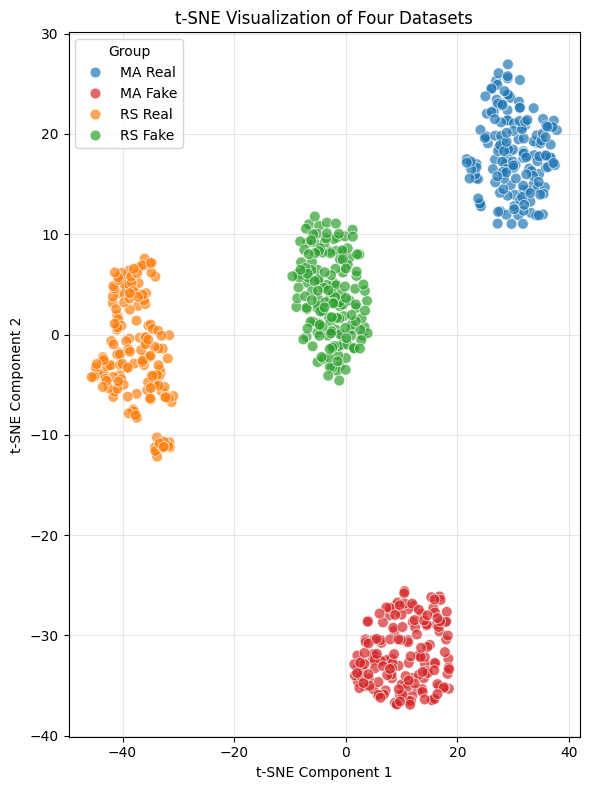

In [25]:
exp='LAML1'
sample=10
ep= '4501'
rep = 0
exp_folder = f'{exp}/{exp}_{sample}_ep{ep}_{rep}'
df_ma_real = pd.read_csv(f'./results/{exp_folder}/Microarray_real.csv',index_col=0)
df_ma_fake = pd.read_csv(f'./results/{exp_folder}/Microarray_fake.csv',index_col=0)
df_rs_real = pd.read_csv(f'./results/{exp_folder}/RNAseq_real.csv',index_col=0)
df_rs_fake = pd.read_csv(f'./results/{exp_folder}/RNAseq_fake.csv',index_col=0)
tsne_results, labels = create_tsne_visualization_seaborn(df_ma_real, df_rs_real, df_rs_fake, df_ma_fake)

In [ ]:
exp='NB'
sample=10
ep= 500
rep = 1
exp_folder = f'{exp}/{exp}_{sample}_ep{ep}_{rep}'
df_ma_real = pd.read_csv(f'./results/{exp_folder}/Microarray_real.csv',index_col=0)
df_ma_fake = pd.read_csv(f'./results/{exp_folder}/Microarray_fake.csv',index_col=0)
df_rs_real = pd.read_csv(f'./results/{exp_folder}/RNAseq_real.csv',index_col=0)
df_rs_fake = pd.read_csv(f'./results/{exp_folder}/RNAseq_fake.csv',index_col=0)
tsne_results, labels = create_tsne_visualization_seaborn(df_ma_real, df_rs_real, df_rs_fake, df_ma_fake)

In [ ]:
pca_results, labels = create_pca_visualization_seaborn(
    df_ma_real, df_rs_real, df_rs_fake, df_ma_fake
)

In [ ]:
# Compute the mean values for comparison

data_means = {
    "Microarray Real": df_ma_real.mean().to_list(),
    "Microarray Syn": df_ma_fake.mean().to_list(),
    "RNAseq Real": df_rs_real.mean().to_list(),
    "RNAseq Syn": df_rs_fake.mean().to_list(),
}

# Create a 4x4 grid of scatter plots
fig, axes = plt.subplots(4, 4, figsize=(6, 8))
fig.suptitle("Pairwise Comparisons of Mean Expression of testing samples", fontsize=16)

# Extract dataset names
data_names = list(data_means.keys())

# Generate scatter plots
for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        if i == j:
            # Plot a histogram for diagonal elements
            sns.histplot(data_means[data_names[i]], bins=30, kde=True, ax=ax, color='gray')
            ax.set_ylabel("Density")
        else:
            # Scatter plot for off-diagonal elements
            sns.scatterplot(x=data_means[data_names[i]], y=data_means[data_names[j]], s=3, ax=ax, color='blue')
        ax.set_xlabel(data_names[i])
        ax.set_ylabel(data_names[j])

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
### DEG endpoint - BRCA
endpoint = pd.read_excel('datasets/TCGA/BRCA/TCGA-CDR-SupplementalTableS1.xlsx',index_col=0).fillna('')

endpoint_pool={}
for ind, d in df_ma_real.iterrows():
    used_ind = ind[:12]
    tmp = endpoint.loc[endpoint['bcr_patient_barcode']==used_ind, 'PFI'].to_list()
    if len(tmp)==1:
        endpoint_pool[ind]=tmp[0]

In [ ]:
### DEG analysis
def get_DEG(data, label):
    list_DEG=[]
    pos_idx,neg_idx = [], []
    for ind, d in data.iterrows():
        if label.get(ind,'')==1:
            pos_idx.append(ind)
        elif label.get(ind,'')==0:
            neg_idx.append(ind)
    
    data_pos = data.loc[pos_idx,:]
    data_neg = data.loc[neg_idx,:]
    
    print(data_pos.shape, data_neg.shape)
    t_stat, p_value = stats.ttest_ind(data_pos, data_neg, equal_var=True)
    # fold_change = data_pos.mean(axis=0) - data_neg.mean(axis=0)
    return p_value # fold_change, 

p_microarray = get_DEG(df_ma_real, endpoint_pool)
p_microarray_fake = get_DEG(df_ma_fake, endpoint_pool)
p_rnaseq = get_DEG(df_rs_real, endpoint_pool)
p_rnaseq_fake = get_DEG(df_rs_fake, endpoint_pool)

print(len(p_microarray), len(p_microarray_fake), len(p_rnaseq), len(p_rnaseq_fake),)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function to compute overlap ratio at different p-value thresholds
def compute_overlap_ratio(p_values1, p_values2, thresholds):
    overlap_ratios = []
    real_deg_counts=[]
    
    for threshold in thresholds:
        # Count values below threshold in each list
        set1 = set(np.where(np.array(p_values1) <= threshold)[0])
        set2 = set(np.where(np.array(p_values2) <= threshold)[0])

        # Compute overlap ratio: intersection size / union size
        if len(set1.union(set2)) > 0:
            overlap_ratio = len(set1.intersection(set2)) / len(set1.union(set2))
        else:
            overlap_ratio = 0

        overlap_ratios.append(overlap_ratio)
        real_deg_counts.append(len(set1))
        
    return overlap_ratios, real_deg_counts

# Define meaningful p-value thresholds (log scale)
thresholds = np.array([0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1])

# Compute overlap trend
overlap_ratios, real_deg_counts = compute_overlap_ratio(p_microarray, p_microarray_fake, thresholds)
overlap_ratios2, real_deg_counts2 = compute_overlap_ratio(p_rnaseq, p_rnaseq_fake, thresholds)

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 3))

# Plot the first two as line plots
ax1.plot(thresholds, overlap_ratios, marker='o', linestyle='-', color='b', label="DEG Overlap Ratio - Microarray")
ax1.plot(thresholds, overlap_ratios2, marker='o', linestyle='-', color='r', label="DEG Overlap Ratio - RNAseq")

# Set x-axis to log scale
ax1.set_xscale("log")
ax1.set_xticks(thresholds)
ax1.set_xticklabels([str(t) for t in thresholds])

# Labels for primary y-axis
ax1.set_xlabel("P-value Threshold (Log Scale)")
ax1.set_ylabel("Overlap Ratio")
ax1.set_ylim(0, 1)
ax1.grid(True, linestyle="--", alpha=0.6)

# Create secondary y-axis
ax2 = ax1.twinx()

# Plot bar charts on the secondary y-axis
bar_width = thresholds*0.3  # Adjust width for better readability
ax2.bar(thresholds-0.6*bar_width, real_deg_counts, width=bar_width, color='blue', alpha=0.5, label="Real DEG Count - Microarray")
ax2.bar(thresholds+0.6*bar_width, real_deg_counts2, width=bar_width, color='lightcoral', alpha=0.5, label="Real DEG Count - RNAseq")

# Labels for secondary y-axis
ax2.set_ylabel("DEG Count")

# Legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("(a). Overlap Ratio and DEG Counts Across P-value Thresholds")
plt.show()